In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
def analyze(dataset_path):
    img_dir  = os.path.join(dataset_path, "images")
    mask_dir = os.path.join(dataset_path, "masks")
    img_files = sorted(os.listdir(img_dir))
 
    heights  = []
    widths   = []
    channels = []
 
    # Dùng để tính mean/std theo công thức online (tránh load toàn bộ vào RAM)
    # Với RGB: tính riêng từng channel (R, G, B)
    # Với Grayscale: tính 1 channel duy nhất
    pixel_sum    = None  # Khởi tạo sau khi biết số channel
    pixel_sq_sum = None
    pixel_count  = 0
 
    for file in img_files:
        img_path = os.path.join(img_dir, file)
        img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        if img is None:
            continue
 
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)
 
        if len(img.shape) == 2:
            # Grayscale
            ch = 1
            channels.append(1)
            img_float = img.astype(np.float64) / 255.0  # (H, W)
            img_float = img_float[np.newaxis, ...]       # (1, H, W)
        else:
            # RGB hoặc BGR (OpenCV đọc là BGR)
            ch = img.shape[2]
            channels.append(ch)
            img_float = img.astype(np.float64) / 255.0  # (H, W, C)
            img_float = img_float[:, :, ::-1]            # BGR -> RGB
            img_float = img_float.transpose(2, 0, 1)     # (C, H, W)
 
        # Khởi tạo accumulator lần đầu
        if pixel_sum is None:
            pixel_sum    = np.zeros(ch, dtype=np.float64)
            pixel_sq_sum = np.zeros(ch, dtype=np.float64)
 
        for c in range(ch):
            pixel_sum[c]    += img_float[c].sum()
            pixel_sq_sum[c] += (img_float[c] ** 2).sum()
            pixel_count     += img_float[c].size if c == 0 else 0
 
    # pixel_count đang tính tổng pixel của 1 channel (tất cả ảnh)
    # Cần tính lại đúng: mỗi channel có cùng số pixel
    total_pixels = pixel_count  # số pixel mỗi channel
 
    mean_vals = pixel_sum    / total_pixels
    std_vals  = np.sqrt(pixel_sq_sum / total_pixels - mean_vals ** 2)
 
    # Xác định loại ảnh chủ yếu trong dataset
    dominant_ch = max(set(channels), key=channels.count)
    img_type    = 'Grayscale' if dominant_ch == 1 else 'RGB'
 
    # Với grayscale, khi repeat thành 3 channel -> mean và std đều nhân 3
    if dominant_ch == 1:
        mean_list = [float(mean_vals[0])] * 3
        std_list  = [float(std_vals[0])]  * 3
    else:
        mean_list = mean_vals.tolist()
        std_list  = std_vals.tolist()
 
    # In kết quả
    avg_h = int(np.mean(heights))
    avg_w = int(np.mean(widths))
 
    print(f"\n📂 Dataset : {dataset_path}")
    print(f"   Số ảnh  : {len(img_files)}")
    print(f"   Avg size: {avg_h} x {avg_w}")
    print(f"   Loại    : {img_type}")
    print(f"   Mean    : {[round(m, 4) for m in mean_list]}")
    print(f"   Std     : {[round(s, 4) for s in std_list]}")

In [3]:
def visualize(dataset_path, sample_size = 3):
    img_dir = os.path.join(dataset_path, "images")
    mask_dir = os.path.join(dataset_path, "masks")

    img_files = sorted(os.listdir(img_dir))
    samples = random.sample(img_files, min(sample_size, len(img_files)))

    plt.figure(figsize=(12, 4 * len(samples)))

    for i, file in enumerate(samples):
        img_path = os.path.join(img_dir, file)
        mask_path = os.path.join(mask_dir, file)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            continue

        mask_bin = (mask > 0).astype(np.uint8)
        if img.shape != mask.shape:
            mask_bin = cv2.resize(mask_bin, (img.shape[1], img.shape[0]))

        overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        alpha = 0.4
        overlay[mask_bin == 1] = (
            (1 - alpha) * overlay[mask_bin == 1] +
            alpha * np.array([255, 0, 0])
        ).astype(np.uint8)

        # ===== plot =====
        plt.subplot(len(samples), 3, i*3 + 1)
        plt.imshow(img, cmap='gray')
        plt.title("Image")
        plt.axis('off')

        plt.subplot(len(samples), 3, i*3 + 2)
        plt.imshow(mask_bin, cmap='gray')
        plt.title("Mask")
        plt.axis('off')

        plt.subplot(len(samples), 3, i*3 + 3)
        plt.imshow(overlay)
        plt.title("Overlay")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [4]:
base = "Datasets"
datasets = ["JSRT", "LUNA", "Shenzhen"]

for ds in datasets:
    train_set = os.path.join(base, ds) + "/train"
    analyze(train_set)


📂 Dataset : Datasets\JSRT/train
   Số ảnh  : 197
   Avg size: 224 x 224
   Loại    : RGB
   Mean    : [0.595, 0.595, 0.595]
   Std     : [0.2743, 0.2743, 0.2743]

📂 Dataset : Datasets\LUNA/train
   Số ảnh  : 210
   Avg size: 512 x 512
   Loại    : Grayscale
   Mean    : [0.8118, 0.8118, 0.8118]
   Std     : [0.3791, 0.3791, 0.3791]

📂 Dataset : Datasets\Shenzhen/train
   Số ảnh  : 452
   Avg size: 512 x 512
   Loại    : RGB
   Mean    : [0.6143, 0.6143, 0.6143]
   Std     : [0.2564, 0.2564, 0.2564]


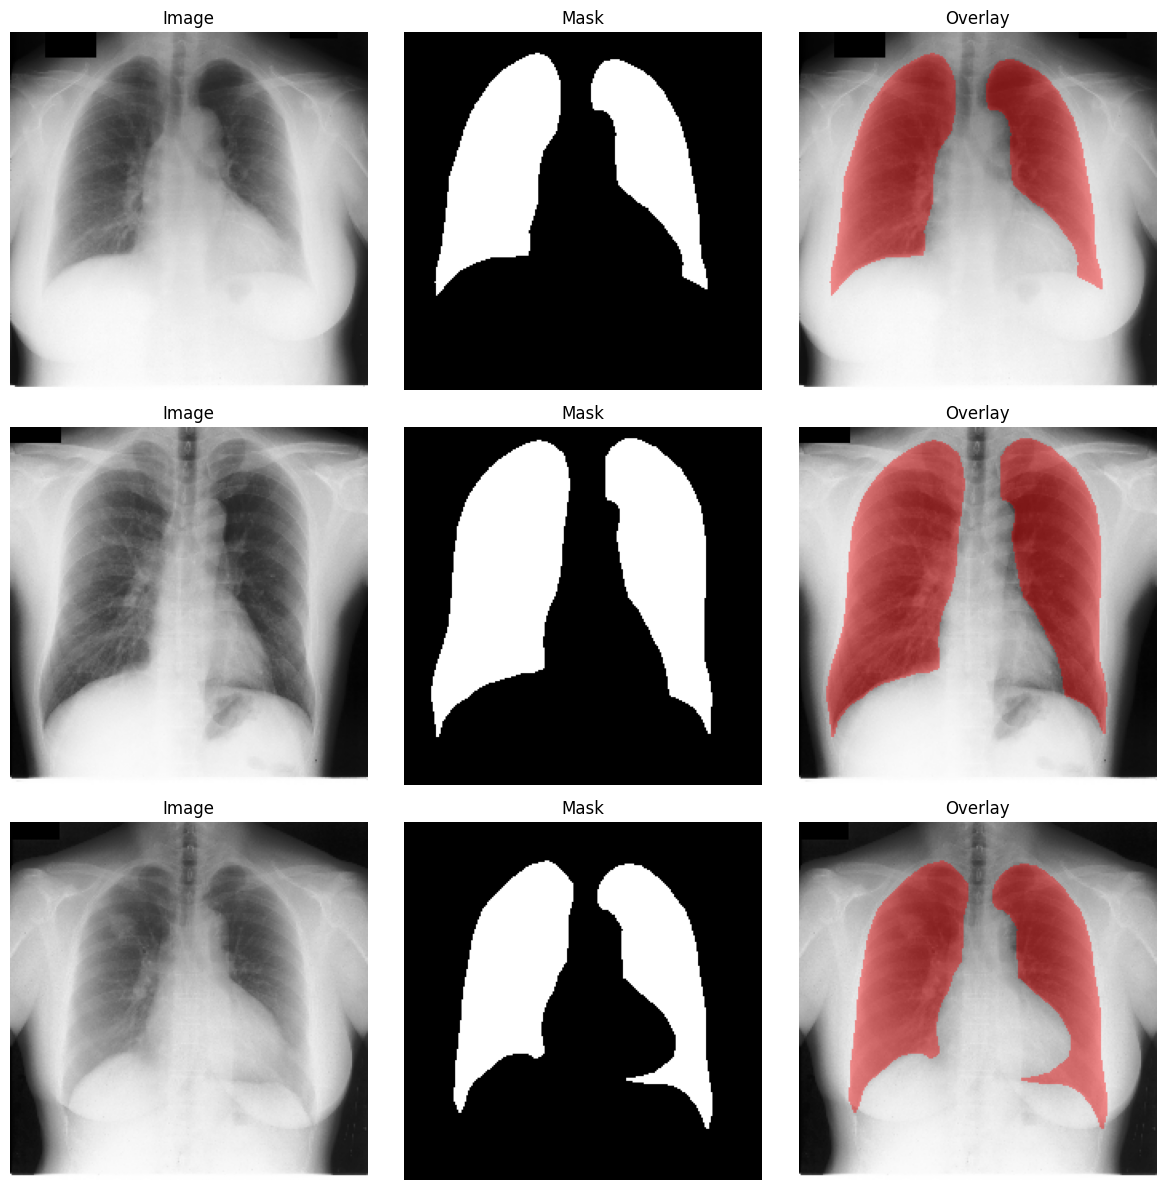

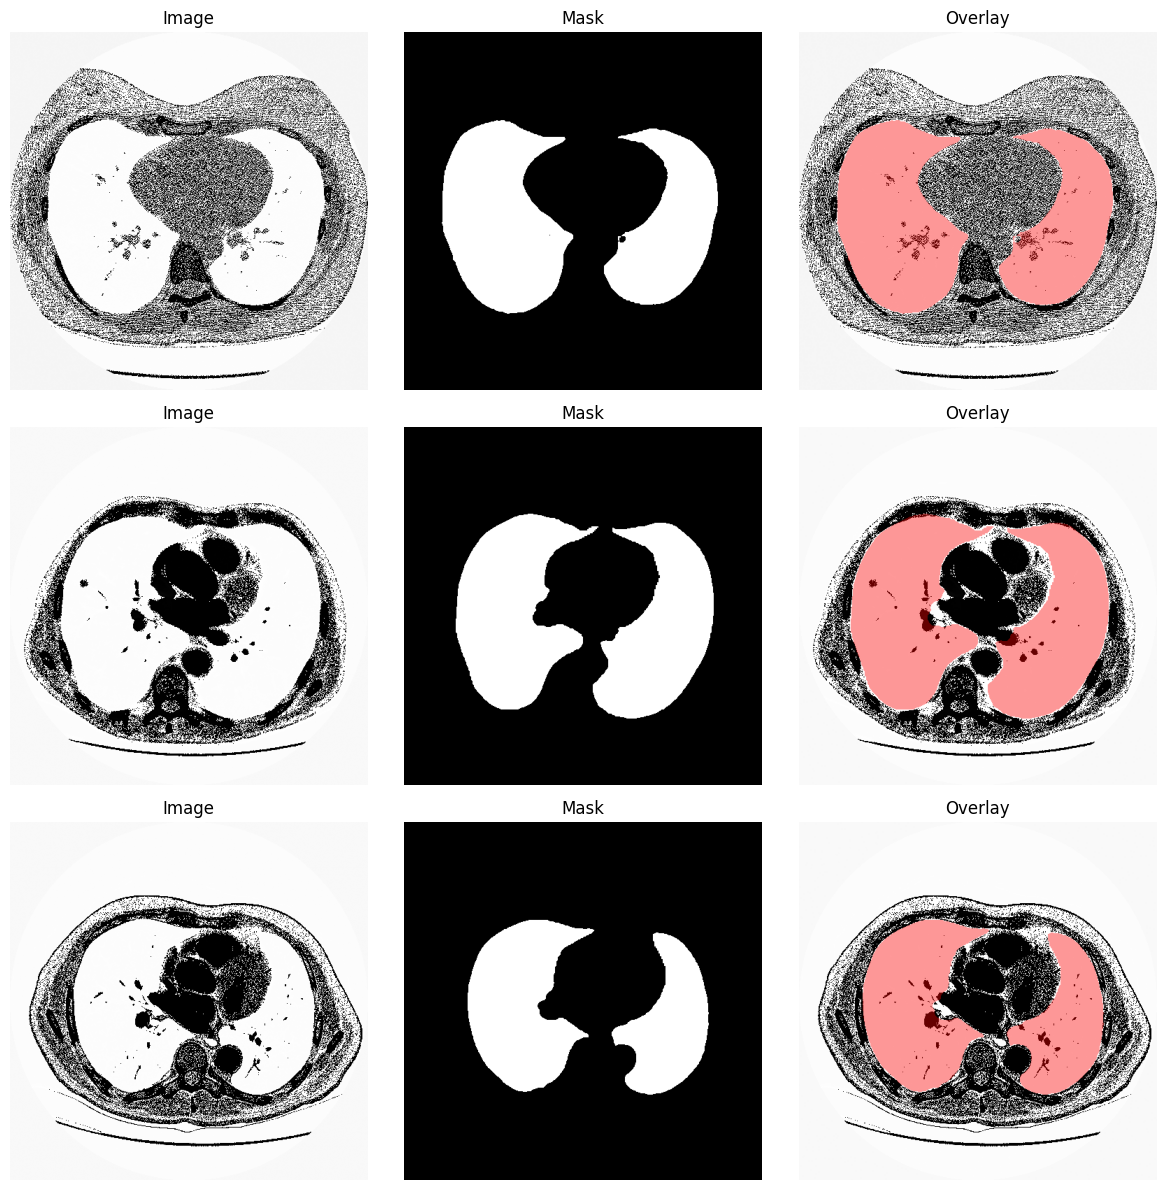

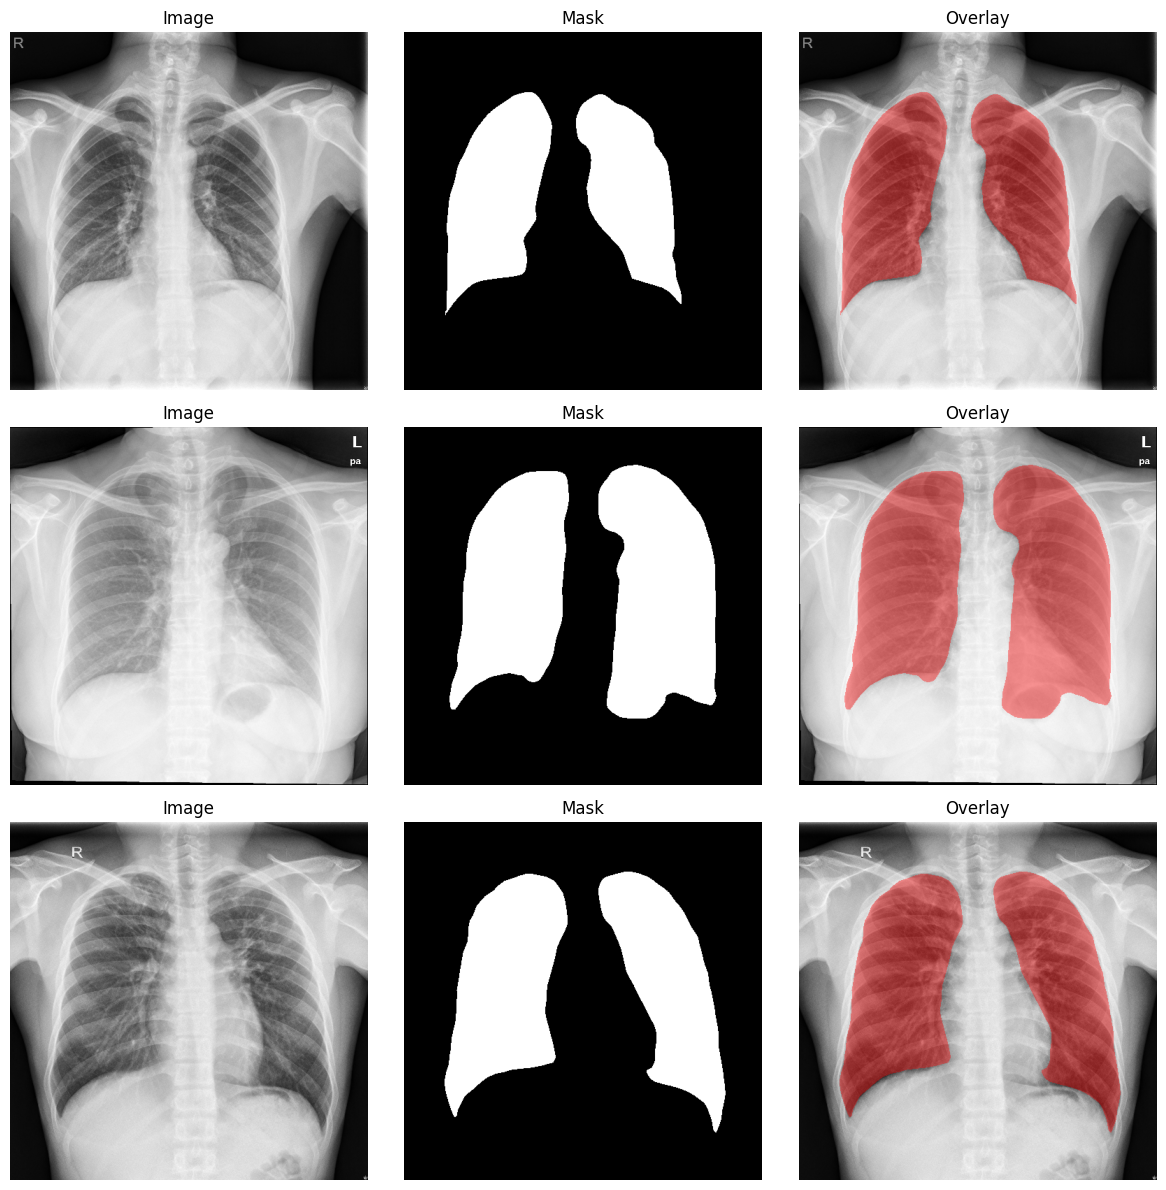

In [5]:
for ds in datasets:
    train_set = os.path.join(base, ds) + "/train"
    visualize(train_set)